In [77]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import patsy
import numpy as np
import statsmodels.api as sm

one row 

In [1558]:
patients_df = pd.read_csv("../data/mjdata.csv", encoding='windows-1252')

KeyboardInterrupt: 

In [1672]:
patients_df.head(10)

,hi_kma_id,hu_kma_id,lo_kma_id,mt_kma_id,hilo_kma_id,lag1_mt_kma_id,lag2_mt_kma_id,lag3_mt_kma_id,lag4_mt_kma_id,lag5_mt_kma_id,...,lag2_hilo_rp1,lag3_hilo_rp1,lag4_hilo_rp1,lag5_hilo_rp1,lag6_hilo_rp1,lag7_hilo_rp1,zip_reg_eng,zip_reg_prim_eng,kmj_date,kma_jid
0,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
1,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
2,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
3,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
4,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
5,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
6,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
7,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
8,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
9,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW


In [1671]:
patients_df.columns

Index(['hi_kma_id', 'hu_kma_id', 'lo_kma_id', 'mt_kma_id', 'hilo_kma_id',
       'lag1_mt_kma_id', 'lag2_mt_kma_id', 'lag3_mt_kma_id', 'lag4_mt_kma_id',
       'lag5_mt_kma_id',
       ...
       'lag2_hilo_rp1', 'lag3_hilo_rp1', 'lag4_hilo_rp1', 'lag5_hilo_rp1',
       'lag6_hilo_rp1', 'lag7_hilo_rp1', 'zip_reg_eng', 'zip_reg_prim_eng',
       'kmj_date', 'kma_jid'],
      dtype='object', length=139)

In [2032]:
def parkinson_check(x):
    return x[lambda a: a.isin(['G20','G21','G22'])].count()
def ibd_check(x):
    return x[lambda a: a.isin(['K50','K51','K52'])].count()


In [2034]:
gk = patients_df.groupby('kma_jid').agg(
    t_max = pd.NamedAgg(column='hi_kma_id', aggfunc='first'),
    t_avg = pd.NamedAgg(column='mt_kma_id', aggfunc='first'),
    hu = pd.NamedAgg(column='hu_kma_id', aggfunc='first'),
    lag1_t_max = pd.NamedAgg(column='lag1_hi_kma_id', aggfunc='first'),
    lag1_hu = pd.NamedAgg(column='lag1_hu_kma_id', aggfunc='first'),
    lag1_t_avg = pd.NamedAgg(column='lag1_mt_kma_id', aggfunc='first'),
    lag2_t_max = pd.NamedAgg(column='lag2_hi_kma_id', aggfunc='first'),
    lag2_hu = pd.NamedAgg(column='lag2_hu_kma_id', aggfunc='first'),
    lag2_t_avg = pd.NamedAgg(column='lag2_mt_kma_id', aggfunc='first'),
    lag3_t_max = pd.NamedAgg(column='lag3_hi_kma_id', aggfunc='first'),
    lag3_hu = pd.NamedAgg(column='lag3_hu_kma_id', aggfunc='first'),
    lag3_t_avg = pd.NamedAgg(column='lag3_mt_kma_id', aggfunc='first'),
    lag4_t_max = pd.NamedAgg(column='lag4_hi_kma_id', aggfunc='first'),
    lag4_hu = pd.NamedAgg(column='lag4_hu_kma_id', aggfunc='first'),
    lag4_t_avg = pd.NamedAgg(column='lag4_mt_kma_id', aggfunc='first'),
    lag5_t_max = pd.NamedAgg(column='lag5_hi_kma_id', aggfunc='first'),
    lag5_hu = pd.NamedAgg(column='lag5_hu_kma_id', aggfunc='first'),
    lag5_t_avg = pd.NamedAgg(column='lag5_mt_kma_id', aggfunc='first'),
    lag6_t_max = pd.NamedAgg(column='lag6_hi_kma_id', aggfunc='first'),
    lag6_hu = pd.NamedAgg(column='lag6_hu_kma_id', aggfunc='first'),
    lag6_t_avg = pd.NamedAgg(column='lag6_mt_kma_id', aggfunc='first'),
    lag7_t_max = pd.NamedAgg(column='lag7_hi_kma_id', aggfunc='first'),
    lag7_hu = pd.NamedAgg(column='lag7_hu_kma_id', aggfunc='first'),
    lag7_t_avg = pd.NamedAgg(column='lag7_mt_kma_id', aggfunc='first'),
    
    pd_in_parkinson = pd.NamedAgg(column='sick_cha3', aggfunc=parkinson_check),
    pd_in_ibd = pd.NamedAgg(column='sick_cha3', aggfunc=ibd_check),
    pd_in_total = pd.NamedAgg(column='sick_cha3', aggfunc='count')
)

We groupby kma_jid

In [2035]:
gk.describe()

,t_max,t_avg,hu,lag1_t_max,lag1_hu,lag1_t_avg,lag2_t_max,lag2_hu,lag2_t_avg,lag3_t_max,...,lag5_t_avg,lag6_t_max,lag6_hu,lag6_t_avg,lag7_t_max,lag7_hu,lag7_t_avg,pd_in_parkinson,pd_in_ibd,pd_in_total
count,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,...,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000
mean,19.119094,14.167365,68.752012,19.115702,68.769273,14.167666,19.125329,68.799883,14.175598,19.130737,...,14.169589,19.130543,68.669305,14.165876,19.122894,68.572909,14.162080,59.030609,2.094049,1188.921512
std,9.812918,9.725769,15.439811,9.817331,15.439414,9.726227,9.808609,15.407955,9.717193,9.794753,...,9.727894,9.803134,15.472796,9.732400,9.814268,15.515257,9.737812,81.876468,2.462174,1255.858003
min,-10.500000,-14.400000,20.900000,-10.500000,20.900000,-14.400000,-10.500000,20.900000,-14.400000,-10.500000,...,-14.400000,-10.500000,20.900000,-14.400000,-10.500000,20.900000,-14.400000,0.000000,0.000000,1.000000
25%,10.900000,5.800000,57.727435,10.900000,57.727435,5.800000,10.948437,57.800000,5.800000,10.937358,...,5.800000,11.000000,57.600000,5.774286,11.000000,57.496667,5.722955,12.000000,0.000000,303.000000
50%,20.523864,15.200000,70.206250,20.522078,70.236667,15.200000,20.523864,70.275556,15.200000,20.522078,...,15.200000,20.522078,70.190693,15.200000,20.523864,70.100000,15.200000,40.000000,1.000000,859.000000
75%,27.151136,22.400000,80.379167,27.151136,80.400000,22.400000,27.157955,80.400000,22.400000,27.151136,...,22.400000,27.169318,80.322476,22.400000,27.157955,80.300000,22.400000,67.000000,3.000000,1491.000000
max,38.100000,32.400000,99.100000,38.100000,99.100000,32.400000,38.100000,99.100000,32.400000,38.100000,...,32.400000,38.100000,99.100000,32.400000,38.100000,99.100000,32.400000,953.000000,16.000000,10726.000000


Seperate location

In [2036]:
gk.reset_index(level=0,inplace=True)

In [2037]:
gk['date'] = gk['kma_jid'].apply(lambda x: x.split('_')[0])

In [2038]:
gk['place'] = gk['kma_jid'].apply(lambda x: x.split('_')[1])

In [2039]:
gk.drop(columns=['kma_jid'])

,t_max,t_avg,hu,lag1_t_max,lag1_hu,lag1_t_avg,lag2_t_max,lag2_hu,lag2_t_avg,lag3_t_max,...,lag6_hu,lag6_t_avg,lag7_t_max,lag7_hu,lag7_t_avg,pd_in_parkinson,pd_in_ibd,pd_in_total,date,place
0,10.900000,5.300000,52.100000,10.500000,51.900000,5.700000,11.000000,41.300000,4.700000,8.300000,...,48.800000,7.600000,9.800000,30.500000,5.500000,583,5,4955,20160101,BS
1,5.633333,0.320000,74.333333,4.546667,78.573333,1.033333,7.066667,66.900000,-0.300000,2.786667,...,63.986667,2.833333,4.206667,44.373333,-0.106667,91,2,939,20160101,CB
2,7.325000,1.975000,81.581250,6.018750,86.050000,1.268750,6.718750,80.837500,1.050000,4.131250,...,75.737500,3.437500,5.325000,57.106250,0.943750,214,1,2174,20160101,CN
3,8.000000,1.700000,70.500000,7.000000,66.400000,2.000000,8.000000,62.000000,0.600000,5.100000,...,51.100000,5.000000,6.300000,43.000000,2.500000,246,2,2918,20160101,DG
4,7.700000,1.600000,77.400000,5.800000,82.500000,1.500000,8.100000,75.100000,1.200000,5.400000,...,66.300000,4.200000,5.900000,52.900000,1.000000,186,2,1765,20160101,DJ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5843,5.846667,1.040000,78.273333,4.306667,68.213333,-2.566667,1.313333,63.166667,-2.173333,4.040000,...,76.213333,2.173333,2.880000,72.400000,-0.200000,21,1,798,20161231,JB
5844,10.300000,7.050000,64.150000,9.000000,64.450000,5.900000,8.600000,62.350000,5.950000,8.900000,...,73.300000,10.550000,9.350000,64.900000,7.300000,3,0,140,20161231,JJ
5845,7.677273,2.363636,75.404545,6.013636,57.445455,0.400000,3.218182,62.445455,0.404545,6.440909,...,74.354545,4.540909,6.109091,65.068182,2.913636,25,2,731,20161231,JN
5846,5.700000,0.700000,65.400000,1.000000,50.900000,-3.900000,-1.100000,53.100000,-4.200000,2.600000,...,69.500000,1.000000,1.100000,66.000000,-2.400000,38,3,1445,20161231,SU


## Only take June -  September

In [2040]:
gk['date'] = [pd.to_datetime(d, format='%Y%m%d') for d in gk['date']]

In [2041]:
gk['month'] = gk['date'].dt.month

In [2042]:
gk['day_of_week'] = gk['date'].dt.dayofweek
gk['day'] = gk['date'].dt.day

In [2043]:
gk['weekdayname'] = gk['date'].dt.weekday_name

In [2044]:
gk = gk[(gk['month'] >= 6) & (gk['month'] <= 9) ]

In [2045]:
gk.describe()

,t_max,t_avg,hu,lag1_t_max,lag1_hu,lag1_t_avg,lag2_t_max,lag2_hu,lag2_t_avg,lag3_t_max,...,lag6_t_avg,lag7_t_max,lag7_hu,lag7_t_avg,pd_in_parkinson,pd_in_ibd,pd_in_total,month,day_of_week,day
count,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,...,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000
mean,28.922759,24.453706,77.834001,28.985288,77.625131,24.483278,29.037774,77.476800,24.501596,29.047010,...,24.462938,29.023750,76.891219,24.449605,60.110826,2.129810,1186.156491,7.499230,2.995382,15.756798
std,3.732001,3.121593,10.438824,3.651680,10.491759,3.081809,3.599947,10.530022,3.060259,3.589992,...,3.098469,3.618095,10.675273,3.116045,85.382693,2.453903,1286.834636,1.111183,1.977927,8.809900
min,18.062500,16.541667,38.300000,18.900000,38.300000,16.755556,18.900000,38.300000,16.755556,18.900000,...,16.755556,18.900000,38.300000,16.755556,0.000000,0.000000,1.000000,6.000000,0.000000,1.000000
25%,26.300000,22.100000,71.404167,26.354167,71.133333,22.150000,26.477273,70.955556,22.176190,26.513636,...,22.080000,26.500000,70.226667,22.050000,12.000000,0.000000,289.000000,7.000000,1.000000,8.000000
50%,28.737500,24.016667,78.427273,28.760000,78.245238,24.018182,28.800000,78.080000,24.025000,28.800000,...,24.000000,28.800000,77.454545,24.000000,40.000000,1.000000,841.000000,7.000000,3.000000,16.000000
75%,31.886667,27.200000,84.931250,31.900000,84.790909,27.200000,31.900000,84.600000,27.204545,31.900000,...,27.204545,31.900000,84.350000,27.204545,68.000000,3.000000,1479.000000,8.000000,5.000000,23.000000
max,38.100000,32.400000,99.100000,38.100000,99.100000,32.400000,38.100000,99.100000,32.400000,38.100000,...,32.400000,38.100000,99.100000,32.400000,934.000000,16.000000,10401.000000,9.000000,6.000000,31.000000


Big change in tmax.

We try to see the functional relationship between admissions due to Parkinson's disease and maximum daily temperature by focusing on one place and one day

In [2046]:
test = gk[(gk['day'].isin([0,1,2,3,4]))]

## Take out 공휴일

In [2048]:
holiday = ['2016-01-01', '2016-02-07','2016-02-08',
           '2016-02-09','2016-02-10', '2016-03-01',
          '2016-04-13', '2016-05-01', '2016-05-05',
          '2016-05-14', '2016-06-06', '2016-08-15',
          '2016-09-14', '2016-09-15', '2016-09-16',
          '2016-10-03', '2016-10-09', '2016-12-25']

In [2049]:
gk['holiday'] = gk['date'].isin(holiday)

In [2050]:
gk['isHW'] = (gk['t_max'] > 33).astype(int)

In [2051]:
for lag in range(1,8):
    gk[f'lag{lag}_isHW'] = (gk[f'lag{lag}_t_max'] > 33).astype(int)

## 1일도 뺌

In [2052]:
gk['HW_diff']  = np.where(gk['t_max'] <= 33, 0, gk['t_max'] - 33)

In [2053]:
for lag in range(1,8):
    gk[f'lag{lag}_HW_diff']  = np.where(gk[f'lag{lag}_t_max'] <= 33, 0, gk[f'lag{lag}_t_max'] - 33)

In [2054]:
gk['is_first'] = (gk['day'] == 1).astype(int)

In [2056]:
gk['is_weekend'] = gk['weekdayname'].isin(['Saturday','Sunday'])

## Add air quality

In [2057]:
airquality_df = pd.read_csv('../data/air_quality_city.csv')

In [2058]:
airquality_df['date'] = pd.to_datetime(airquality_df['date'])

In [2059]:
gk = pd.merge(gk, airquality_df, on=['place','date'], how ="left")


In [2061]:
gk.to_csv('../data/ibd_airquality.csv')

In [2065]:
gk

,kma_jid,t_max,t_avg,hu,lag1_t_max,lag1_hu,lag1_t_avg,lag2_t_max,lag2_hu,lag2_t_avg,...,lag6_HW_diff,lag7_HW_diff,is_first,is_weekend,SO2,CO,O3,NO2,PM10,PM25
0,20160601_BS,23.600000,20.700000,53.500000,30.500000,55.100000,23.800000,26.600000,62.300000,22.400000,...,0.0,0.0,1,False,0.005238,0.348544,0.054248,0.015004,44.443992,21.502033
1,20160601_CB,27.686667,21.880000,49.233333,28.313333,58.246667,21.780000,28.893333,55.246667,21.426667,...,0.0,0.0,1,False,0.003156,0.309302,0.040550,0.012832,48.490272,29.690987
2,20160601_CN,28.043750,21.600000,68.412500,26.250000,76.681250,20.368750,27.968750,72.862500,20.400000,...,0.0,0.0,1,False,0.003075,0.426484,0.053128,0.017975,58.891892,29.901408
3,20160601_DG,25.100000,20.600000,52.000000,30.800000,47.100000,25.200000,32.300000,52.900000,24.600000,...,0.0,0.0,1,False,0.002846,0.284859,0.053713,0.008640,39.975610,17.552083
4,20160601_DJ,28.400000,22.900000,59.100000,27.900000,64.900000,22.000000,29.400000,66.000000,22.000000,...,0.0,0.0,1,False,0.002288,0.377083,0.050175,0.016821,46.189076,24.972222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1944,20160930_JB,19.473333,17.640000,93.653333,23.660000,85.273333,20.640000,24.326667,88.160000,21.253333,...,0.0,0.0,0,False,0.003388,0.373698,0.012762,0.015052,24.428571,14.188285
1945,20160930_JJ,23.500000,21.600000,93.950000,23.050000,96.150000,21.650000,24.800000,96.600000,23.400000,...,0.0,0.0,0,False,0.001142,0.263158,0.026427,0.005609,18.730159,8.069767
1946,20160930_JN,19.568182,18.231818,94.604545,22.531818,90.868182,20.495455,24.045455,94.586364,21.959091,...,0.0,0.0,0,False,0.003529,0.349858,0.018907,0.011967,15.397333,7.685446
1947,20160930_SU,23.500000,20.500000,66.900000,24.800000,64.400000,20.400000,21.800000,84.600000,19.900000,...,0.0,0.0,0,False,0.004389,0.495760,0.010670,0.035622,31.240893,13.561111


In [2068]:
gk.columns

Index(['kma_jid', 't_max', 't_avg', 'hu', 'lag1_t_max', 'lag1_hu',
       'lag1_t_avg', 'lag2_t_max', 'lag2_hu', 'lag2_t_avg', 'lag3_t_max',
       'lag3_hu', 'lag3_t_avg', 'lag4_t_max', 'lag4_hu', 'lag4_t_avg',
       'lag5_t_max', 'lag5_hu', 'lag5_t_avg', 'lag6_t_max', 'lag6_hu',
       'lag6_t_avg', 'lag7_t_max', 'lag7_hu', 'lag7_t_avg', 'pd_in_parkinson',
       'pd_in_ibd', 'pd_in_total', 'date', 'place', 'month', 'day_of_week',
       'day', 'weekdayname', 'holiday', 'isHW', 'lag1_isHW', 'lag2_isHW',
       'lag3_isHW', 'lag4_isHW', 'lag5_isHW', 'lag6_isHW', 'lag7_isHW',
       'HW_diff', 'lag1_HW_diff', 'lag2_HW_diff', 'lag3_HW_diff',
       'lag4_HW_diff', 'lag5_HW_diff', 'lag6_HW_diff', 'lag7_HW_diff',
       'is_first', 'is_weekend', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM25'],
      dtype='object')

## Describe

In [2079]:
description_df = gk[gk['place'] == 'SU'][['t_max', 't_avg', 'hu', 'pd_in_parkinson', 'pd_in_ibd', 'pd_in_total', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM25']].describe()

In [2083]:
import math
import xlsxwriter
writer = pd.ExcelWriter('../data/describe.xlsx', engine='xlsxwriter')
for city in interested_places:
    
    s = gk[gk['place'] == city][['t_max', 't_avg', 'hu', 'pd_in_parkinson', 'pd_in_ibd', 'pd_in_total', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM25']].describe()
#     s.to_csv(f'../data/statistics/{city}.csv')
    s.to_excel(writer, sheet_name=f'{city}')
s = gk[['t_max', 't_avg', 'hu', 'pd_in_parkinson', 'pd_in_ibd', 'pd_in_total', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM25']].describe()
s.to_excel(writer, sheet_name='total')
writer.save()

In [2067]:
for city in interested_places:
    gk[gk['place'] == 'SU'][['t_max', 't_avg', 'hu', 'pd_in_parkinson', 'pd_in_ibd', 'pd_in_total', 'SO2', 'CO', 'O3', 'NO2', 'PM10', 'PM25']].describe()

['SU', 'BS', 'DG', 'GJ', 'DJ', 'IC', 'US']

## Add new threshold

In [1887]:
seoul_df = gk[gk['place'] == 'BS']
seoul_df
threshold = seoul_df['t_avg'].quantile(.95)
seoul_df['is_95'] = seoul_df['t_avg'] > threshold

/Users/jaemincheun/anaconda3/envs/parkinson/lib/python3.6/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


# Environmental Variable

In [1976]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
O3 +
NO2 +
PM10
"""

In [1977]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1978]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1979]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1927
Model Family:                 Poisson   Df Model:                           21
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9690.4
Date:                Sun, 01 Dec 2019   Deviance:                       9673.0
Time:                        22:25:38   Pearson chi2:                 9.03e+03
No. Iterations:                     7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3736      0

In [1950]:
gk.to_csv('../data/data_with_air.csv', index=False)

# Lag 0

In [1258]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
hu +
HW_diff
"""

In [1259]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1260]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1261]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1928
Model Family:                 Poisson   Df Model:                           20
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9707.7
Date:                Tue, 26 Nov 2019   Deviance:                       9707.5
Time:                        22:31:23   Pearson chi2:                 9.08e+03
No. Iterations:                     7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.7174      0

# Lag 4

In [1262]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
lag4_isHW
"""

In [1263]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1264]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1265]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1929
Model Family:                 Poisson   Df Model:                           19
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9744.6
Date:                Tue, 26 Nov 2019   Deviance:                       9781.2
Time:                        22:31:25   Pearson chi2:                 9.15e+03
No. Iterations:                     7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.5149      0

# Lag 6


In [1266]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
lag6_isHW
"""

In [1267]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1268]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

## 질환있는 사람

In [1269]:
gk

,kma_jid,t_max,hu,lag1_t_max,lag1_hu,lag2_t_max,lag2_hu,lag3_t_max,lag3_hu,lag4_t_max,...,HW_diff,lag1_HW_diff,lag2_HW_diff,lag3_HW_diff,lag4_HW_diff,lag5_HW_diff,lag6_HW_diff,lag7_HW_diff,is_first,is_weekend
2430,20160601_BS,23.600000,53.500000,30.500000,55.100000,26.600000,62.300000,25.400000,75.400000,24.100000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
2431,20160601_CB,27.686667,49.233333,28.313333,58.246667,28.893333,55.246667,26.600000,54.820000,27.966667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
2432,20160601_CN,28.043750,68.412500,26.250000,76.681250,27.968750,72.862500,26.112500,70.456250,26.337500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
2433,20160601_DG,25.100000,52.000000,30.800000,47.100000,32.300000,52.900000,28.600000,57.800000,29.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
2434,20160601_DJ,28.400000,59.100000,27.900000,64.900000,29.400000,66.000000,26.900000,60.800000,28.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4374,20160930_JB,19.473333,93.653333,23.660000,85.273333,24.326667,88.160000,30.006667,84.373333,28.206667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,False
4375,20160930_JJ,23.500000,93.950000,23.050000,96.150000,24.800000,96.600000,28.000000,90.950000,26.250000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,False
4376,20160930_JN,19.568182,94.604545,22.531818,90.868182,24.045455,94.586364,30.168182,86.986364,27.772727,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,False
4377,20160930_SU,23.500000,66.900000,24.800000,64.400000,21.800000,84.600000,23.800000,82.500000,28.900000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,False


In [640]:
patients_df['sick_cha3']

0          M47
1          G20
2          I10
3          F02
4          E11
          ... 
6952817    M65
6952818    M47
6952819    M17
6952820    K30
6952821    G57
Name: sick_cha3, Length: 6952822, dtype: object

In [642]:
patients_df.head(4)

,hi_kma_id,hu_kma_id,lo_kma_id,mt_kma_id,hilo_kma_id,lag1_mt_kma_id,lag2_mt_kma_id,lag3_mt_kma_id,lag4_mt_kma_id,lag5_mt_kma_id,...,lag2_hilo_rp1,lag3_hilo_rp1,lag4_hilo_rp1,lag5_hilo_rp1,lag6_hilo_rp1,lag7_hilo_rp1,zip_reg_eng,zip_reg_prim_eng,kmj_date,kma_jid
0,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
1,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
2,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW
3,5.305556,65.922222,-4.338889,0.861111,9.644444,1.444444,-0.344444,-3.677778,-4.822222,-2.922222,...,12,13,10,8,9,8,GW,NaN,20160101,20160101_GW


In [647]:
patients_df[['sick_cha1', 'sick_cha2', 'sick_cha3']]

,sick_cha1,sick_cha2,sick_cha3
0,M,M4,M47
1,G,G2,G20
2,I,I1,I10
3,F,F0,F02
4,E,E1,E11
...,...,...,...
6952817,M,M6,M65
6952818,M,M4,M47
6952819,M,M1,M17
6952820,K,K3,K30


In [648]:
Counter(patients_df['no'])

Counter({1730: 148,
         8640: 551,
         21916: 587,
         22713: 201,
         33491: 142,
         40021: 36,
         51393: 162,
         69575: 132,
         85439: 82,
         88340: 68,
         91581: 96,
         96718: 6,
         99035: 84,
         110012: 115,
         130982: 133,
         164903: 248,
         180831: 219,
         181506: 26,
         182851: 149,
         183414: 100,
         185135: 84,
         188468: 48,
         194230: 133,
         195736: 55,
         220708: 1814,
         299311: 60,
         307850: 191,
         311207: 55,
         311992: 1373,
         330512: 101,
         344884: 66,
         353025: 87,
         353817: 122,
         356425: 145,
         363826: 496,
         366668: 120,
         367660: 132,
         397262: 616,
         402670: 748,
         428434: 427,
         438972: 161,
         443937: 160,
         486676: 119,
         503932: 191,
         506832: 154,
         524692: 60,
         526145: 

In [663]:
gi_list = ['K50','K52','K58','K59','A08', 'A09', 'A05', 'R13', 'R11', 'R12', 'R10']
test = patients_df.groupby('no').agg(
    parkinson = pd.NamedAgg(column='sick_cha3', aggfunc=lambda x: x[lambda a: a.isin(['G20','G21','G22'])].count()),
    gi = pd.NamedAgg(column='sick_cha3', aggfunc=lambda x: x[lambda a: a.isin(gi_list)].count())
)

KeyError: "None of [MultiIndex([('sick_cha3', '<lambda>'),\n            ('sick_cha3', '<lambda>')],\n           )] are in the [columns]"

In [ ]:
test.head(10)

In [787]:
Counter(gk['isHW'])

Counter({0: 1628, 1: 321})

In [791]:
temp_df = patients_df[patients_df['hi_kma_id'] >= 33]

AttributeError: 'Counter' object has no attribute 'sort_values'

In [798]:
from collections import Counter, OrderedDict
y = OrderedDict(Counter(temp_df['sick_cha3']).most_common())

In [799]:
y

OrderedDict([('K29', 22276),
             ('M54', 15685),
             ('I10', 14587),
             ('G20', 13521),
             ('E78', 9258),
             ('E11', 8853),
             ('M17', 8799),
             ('M79', 7514),
             ('K59', 7398),
             ('F00', 7047),
             ('M48', 6904),
             ('K21', 6860),
             ('F41', 6268),
             ('K30', 5743),
             ('F32', 5584),
             ('I63', 3973),
             ('J30', 3926),
             ('M81', 3768),
             ('M13', 3666),
             ('G21', 3646),
             ('N40', 3522),
             ('G47', 3520),
             ('H81', 3367),
             ('M25', 3172),
             ('M51', 3128),
             ('M47', 3080),
             ('M75', 3045),
             ('J20', 2878),
             ('R42', 2868),
             ('N31', 2819),
             ('H04', 2759),
             ('I73', 2753),
             ('G25', 2690),
             ('H10', 2664),
             ('I20', 2541),
             ('F

In [800]:
not_df = patients_df[patients_df['hi_kma_id'] <= 33]

In [801]:
from collections import Counter, OrderedDict
x = OrderedDict(Counter(not_df['sick_cha3']).most_common())

In [802]:
x

OrderedDict([('K29', 382754),
             ('M54', 267702),
             ('I10', 256115),
             ('G20', 240707),
             ('E78', 152953),
             ('M17', 152233),
             ('E11', 147483),
             ('M79', 129196),
             ('F00', 126838),
             ('K59', 125307),
             ('K21', 117662),
             ('M48', 111296),
             ('F41', 107163),
             ('K30', 98797),
             ('F32', 94676),
             ('J30', 93854),
             ('J20', 72774),
             ('I63', 68195),
             ('M81', 63061),
             ('G21', 62971),
             ('G47', 62607),
             ('M13', 60128),
             ('N40', 59075),
             ('M25', 54499),
             ('H81', 52489),
             ('M75', 51749),
             ('M51', 50602),
             ('M47', 48833),
             ('N31', 48236),
             ('H04', 47227),
             ('I73', 44864),
             ('I20', 44448),
             ('F51', 44076),
             ('R42', 43582),
 

In [810]:
Counter(gk['place'])

Counter({'BS': 122,
         'CB': 122,
         'CN': 122,
         'DG': 122,
         'DJ': 122,
         'GB': 122,
         'GG': 122,
         'GJ': 120,
         'GN': 122,
         'GW': 122,
         'IC': 122,
         'JB': 122,
         'JJ': 121,
         'JN': 122,
         'SU': 122,
         'US': 122})

In [932]:
seoul = gk[gk['place']=='BS']

In [1227]:
Counter(seoul['isHW'])

Counter({0: 114, 1: 8})

In [931]:
expr = """pd_in ~ 
holiday +
is_weekend +
is_first + 
hu +
lag6_HW_diff
"""

y, X = dmatrices(expr, seoul, return_type='dataframe')

poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                  122
Model:                            GLM   Df Residuals:                      116
Model Family:                 Poisson   Df Model:                            5
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -567.92
Date:                Sun, 24 Nov 2019   Deviance:                       495.20
Time:                        14:09:29   Pearson chi2:                     441.
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.1729      0

### 

In [936]:
gk.to_csv('../data/processed.csv')

In [1508]:
test = pd.read_csv("../data/2016_1.csv", encoding='EUC-KR')

## 서울

In [1542]:
seoul_air_df = test[test['지역'] == '서울']

In [1543]:
seoul_air_df.head(3)

,지역,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
404040,서울,111121,중구,2016010101,0.007,1.0,0.002,0.076,77.0,53.0,서울 중구 덕수궁길 15
404041,서울,111121,중구,2016010102,0.007,1.1,0.002,0.077,70.0,48.0,서울 중구 덕수궁길 15
404042,서울,111121,중구,2016010103,0.007,1.2,0.002,0.078,75.0,53.0,서울 중구 덕수궁길 15


In [1555]:
import datetime as dt
def my_to_datetime(date_str):
    date_str = str(date_str)
    if date_str[8:10] != '24':
        return pd.to_datetime(date_str, format='%Y%m%d%H').date()

    date_str = date_str[0:8] + '00' + date_str[10:]
    return pd.to_datetime(date_str, format='%Y%m%d%H').date() + \
           dt.timedelta(days=1)

In [1556]:
seoul_air_df['date'] = [my_to_datetime(d) for d in seoul_air_df['측정일시']]

/Users/jaemincheun/anaconda3/envs/parkinson/lib/python3.6/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [1557]:
seoul_air_df['date']

404040    2016-01-01
404041    2016-01-01
404042    2016-01-01
404043    2016-01-01
404044    2016-01-01
             ...    
489211    2016-03-31
489212    2016-03-31
489213    2016-03-31
489214    2016-03-31
489215    2016-04-01
Name: date, Length: 85176, dtype: object

In [1980]:
gk

,kma_jid,t_max,t_avg,hu,lag1_t_max,lag1_hu,lag1_t_avg,lag2_t_max,lag2_hu,lag2_t_avg,...,lag7_HW_diff,is_first,is_weekend,is_98,SO2,CO,O3,NO2,PM10,PM25
0,20160601_BS,23.600000,20.700000,53.500000,30.500000,55.100000,23.800000,26.600000,62.300000,22.400000,...,0.0,1,False,NaN,0.005238,0.348544,0.054248,0.015004,44.443992,21.502033
1,20160601_CB,27.686667,21.880000,49.233333,28.313333,58.246667,21.780000,28.893333,55.246667,21.426667,...,0.0,1,False,NaN,0.003156,0.309302,0.040550,0.012832,48.490272,29.690987
2,20160601_CN,28.043750,21.600000,68.412500,26.250000,76.681250,20.368750,27.968750,72.862500,20.400000,...,0.0,1,False,NaN,0.003075,0.426484,0.053128,0.017975,58.891892,29.901408
3,20160601_DG,25.100000,20.600000,52.000000,30.800000,47.100000,25.200000,32.300000,52.900000,24.600000,...,0.0,1,False,NaN,0.002846,0.284859,0.053713,0.008640,39.975610,17.552083
4,20160601_DJ,28.400000,22.900000,59.100000,27.900000,64.900000,22.000000,29.400000,66.000000,22.000000,...,0.0,1,False,NaN,0.002288,0.377083,0.050175,0.016821,46.189076,24.972222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1944,20160930_JB,19.473333,17.640000,93.653333,23.660000,85.273333,20.640000,24.326667,88.160000,21.253333,...,0.0,0,False,NaN,0.003388,0.373698,0.012762,0.015052,24.428571,14.188285
1945,20160930_JJ,23.500000,21.600000,93.950000,23.050000,96.150000,21.650000,24.800000,96.600000,23.400000,...,0.0,0,False,NaN,0.001142,0.263158,0.026427,0.005609,18.730159,8.069767
1946,20160930_JN,19.568182,18.231818,94.604545,22.531818,90.868182,20.495455,24.045455,94.586364,21.959091,...,0.0,0,False,NaN,0.003529,0.349858,0.018907,0.011967,15.397333,7.685446
1947,20160930_SU,23.500000,20.500000,66.900000,24.800000,64.400000,20.400000,21.800000,84.600000,19.900000,...,0.0,0,False,NaN,0.004389,0.495760,0.010670,0.035622,31.240893,13.561111


## By city

In [1983]:
init_variables = [
    'isHW',
    'HW_diff',
    't_max',
    't_avg'
]
variables = []
for v in init_variables:
    variables.append(v)
    for i in range(1,8):
        variables.append(f'lag{i}_{v}')

In [1985]:
def equat(x):
    return (x-1)/x

In [1986]:
interested_places = ['SU', 'BS', 'DG', 'GJ', 'DJ', 'IC', 'US']

In [1987]:
import math
import xlsxwriter
writer = pd.ExcelWriter('../data/june_glm_pm_allvariables.xlsx', engine='xlsxwriter')
for city in interested_places:
    info_dict = {}
    for variable in variables:
        expr = f"""pd_in ~ 
        holiday +
        is_weekend +
        is_first + 
        hu +
        PM10 +
        O3 +
        PM10 +
        {variable}
        """
        gk_city = gk[gk['place'] == city]
        y, X = dmatrices(expr, gk_city, return_type='dataframe')
        poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()
        temp = {}
        temp['coefficient'] = poisson_training_results.params[variable]
        temp['pvalue'] = poisson_training_results.pvalues[variable]
        conf_interval = poisson_training_results.conf_int().iloc[5]
        low_conf, high_conf = conf_interval[0], conf_interval[1]
        temp['lowerCI'] = low_conf
        temp['higherCI'] = high_conf
        temp['RR'] = math.exp(temp['coefficient'])
        temp['lowerRRCI'] = math.exp(temp['lowerCI'])
        temp['higherRRCI'] = math.exp(temp['higherCI'])
        temp['AR'] = equat(temp['RR'])
        temp['lowerARCI'] = equat(temp['lowerRRCI'])
        temp['higherARCI'] = equat(temp['higherRRCI'])
        temp['isSignificant'] = poisson_training_results.pvalues[variable] < 0.05
        info_dict[variable] = temp
    s = pd.DataFrame(info_dict)
#     s.to_csv(f'../data/statistics/{city}.csv')
    s.to_excel(writer, sheet_name=f'{city}')
writer.save()

In [1274]:
info_dict = {}
for variable in variables:
    expr = f"""pd_in ~ 
    holiday +
    is_weekend +
    is_first + 
    hu +
    place +
    {variable}
    """
    gk_city = gk
    y, X = dmatrices(expr, gk_city, return_type='dataframe')
    poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    temp = {}
    temp['coefficient'] = poisson_training_results.params[variable]
    temp['pvalue'] = poisson_training_results.pvalues[variable]
    conf_interval = poisson_training_results.conf_int().iloc[-1]
    low_conf, high_conf = conf_interval[0], conf_interval[1]
    temp['lowerCI'] = low_conf
    temp['higherCI'] = high_conf
    temp['RR'] = math.exp(temp['coefficient'])
    temp['lowerRRCI'] = math.exp(temp['lowerCI'])
    temp['higherRRCI'] = math.exp(temp['higherCI'])
    temp['AR'] = equat(temp['RR'])
    temp['lowerARCI'] = equat(temp['lowerRRCI'])
    temp['higherARCI'] = equat(temp['higherRRCI'])
    temp['isSignificant'] = poisson_training_results.pvalues[variable] < 0.05
    info_dict[variable] = temp
s = pd.DataFrame(info_dict)
s.to_csv(f'../data/statistics/june_all.csv')

In [1276]:
list(Counter(gk['place']).keys())

['BS',
 'CB',
 'CN',
 'DG',
 'DJ',
 'GB',
 'GG',
 'GJ',
 'GN',
 'GW',
 'IC',
 'JB',
 'JJ',
 'JN',
 'SU',
 'US']

In [1277]:
interested_places = ['SU', 'BS', 'DG', 'GJ', 'DJ', 'IC', 'US']

In [1289]:
gk.columns

Index(['kma_jid', 't_max', 'hu', 'lag1_t_max', 'lag1_hu', 'lag2_t_max',
       'lag2_hu', 'lag3_t_max', 'lag3_hu', 'lag4_t_max', 'lag4_hu',
       'lag5_t_max', 'lag5_hu', 'lag6_t_max', 'lag6_hu', 'lag7_t_max',
       'lag7_hu', 'pd_in', 'date', 'place', 'month', 'day_of_week', 'day',
       'weekdayname', 'holiday', 'isHW', 'lag1_isHW', 'lag2_isHW', 'lag3_isHW',
       'lag4_isHW', 'lag5_isHW', 'lag6_isHW', 'lag7_isHW', 'HW_diff',
       'lag1_HW_diff', 'lag2_HW_diff', 'lag3_HW_diff', 'lag4_HW_diff',
       'lag5_HW_diff', 'lag6_HW_diff', 'lag7_HW_diff', 'is_first',
       'is_weekend'],
      dtype='object')

In [1343]:
finished_city = []

In [1357]:
city = 'US'
temp = gk[gk['place'] == city]

finished_city.append(city)
temp.describe()['t_max']

count    122.000000
mean      27.886066
std        3.749718
min       18.900000
25%       25.025000
50%       27.550000
75%       30.750000
max       35.700000
Name: t_max, dtype: float64

Text(0.5, 1.0, 'Density Plot and Histogram of T_max in US')

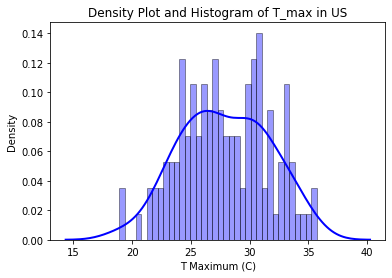

In [1358]:
import seaborn as sns
# seaborn histogram
sns.distplot(temp['t_max'], hist=True, kde=True, 
             bins=int(180/5), color = 'blue',
             hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 2})
plt.xlabel("T Maximum (C)")
plt.ylabel("Density")
plt.title(f"Density Plot and Histogram of T_max in {city}")

Text(0.5, 1.0, 'Change in temperature in US')

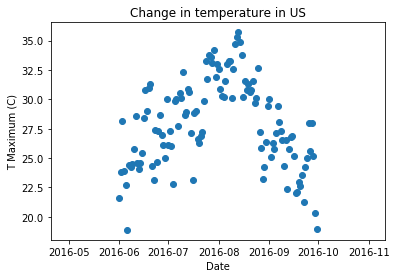

In [1359]:
plt.scatter(temp['date'], temp['t_max'])
plt.xlabel("Date")
plt.ylabel("T Maximum (C)")
plt.title(f"Change in temperature in {city}")

Text(0.5, 1.0, 'T_max vs Pd_in in US')

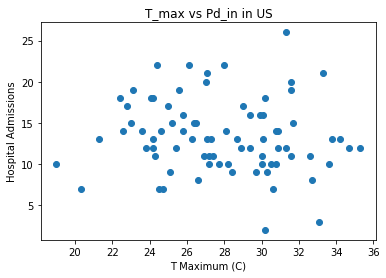

In [1360]:
temp1 = temp[~temp['is_weekend'] & ~temp['is_first'] & ~temp['holiday']]
plt.scatter(temp1['t_max'], temp1['pd_in'])
plt.xlabel("T Maximum (C)")
plt.ylabel("Hospital Admissions")
plt.title(f"T_max vs Pd_in in {city}")

In [1361]:
finished_city

['GJ', 'GJ', 'IC', 'SU', 'US']

In [1366]:
parkinson_code = ['G20','G21','G22']
gastro_code = ['K50', 'K52', 'K58', 'K59', 'A08', 'A09', 'A05', 'R13', 'R12', 'R11', 'R10']

In [1364]:
gastro_df = patients_df[patients_df['sick_cha3'].isin(gastro_code)]

In [1369]:
gastro_df.shape

(279834, 139)

In [1392]:
parkinson_df = patients_df[patients_df['sick_cha3'].isin(parkinson_code)]

In [1402]:
parkinson_df['no'].unique().shape

(36595,)

In [1403]:
patients_df['no'].unique().shape

(36595,)

In [1394]:
total_patients = patients_df['no'].unique()

In [1395]:
len(total_patients)

36595

In [1396]:
parkinson_patients = parkinson_df['no'].unique()

In [1397]:
len(parkinson_patients)

36595

In [1390]:
gastro_parkinson_patients = gastro_df[gastro_df['no'].isin(parkinson_patients)]['no'].unique()
gastro_patients = gastro_df['no'].unique()

In [1391]:
print(f'number of total patients: {len(total_patients)}')
print(f'number of parkinson patients: {len(parkinson_patients)}')
print(f'proportion of parkinson patients of all: {len(parkinson_patients)/len(total_patients)}')
print(f'number of gastro patients: {len(gastro_patients)}')
print(f'number of parkinson + gastro patients: {len(gastro_parkinson_patients)}')
print(f'proportion of parkinson out of all gastro: {len(gastro_parkinson_patients)/len(gastro_patients)}')

number of total patients: 36595
number of parkinson patients: 36595
proportion of parkinson patients of all: 1.0
number of gastro patients: 26106
number of parkinson + gastro patients: 26106
proportion of parkinson out of all gastro: 1.0


## 위 질환


In [1404]:
gk = patients_df.groupby('kma_jid').agg(
    t_max = pd.NamedAgg(column='hi_kma_id', aggfunc='first'),
    hu = pd.NamedAgg(column='hu_kma_id', aggfunc='first'),
    lag1_t_max = pd.NamedAgg(column='lag1_hi_kma_id', aggfunc='first'),
    lag1_hu = pd.NamedAgg(column='lag1_hu_kma_id', aggfunc='first'),
    lag2_t_max = pd.NamedAgg(column='lag2_hi_kma_id', aggfunc='first'),
    lag2_hu = pd.NamedAgg(column='lag2_hu_kma_id', aggfunc='first'),
    lag3_t_max = pd.NamedAgg(column='lag3_hi_kma_id', aggfunc='first'),
    lag3_hu = pd.NamedAgg(column='lag3_hu_kma_id', aggfunc='first'),
    lag4_t_max = pd.NamedAgg(column='lag4_hi_kma_id', aggfunc='first'),
    lag4_hu = pd.NamedAgg(column='lag4_hu_kma_id', aggfunc='first'),
    lag5_t_max = pd.NamedAgg(column='lag5_hi_kma_id', aggfunc='first'),
    lag5_hu = pd.NamedAgg(column='lag5_hu_kma_id', aggfunc='first'),
    lag6_t_max = pd.NamedAgg(column='lag6_hi_kma_id', aggfunc='first'),
    lag6_hu = pd.NamedAgg(column='lag6_hu_kma_id', aggfunc='first'),
    lag7_t_max = pd.NamedAgg(column='lag7_hi_kma_id', aggfunc='first'),
    lag7_hu = pd.NamedAgg(column='lag7_hu_kma_id', aggfunc='first'),
    pd_in = pd.NamedAgg(column='sick_cha3', aggfunc=lambda x: x[lambda a: a.isin(gastro_code)].count())
#         pd_in = pd.NamedAgg(column='sick_cha3', aggfunc='count')
)

We groupby kma_jid

In [1405]:
gk.describe()

,t_max,hu,lag1_t_max,lag1_hu,lag2_t_max,lag2_hu,lag3_t_max,lag3_hu,lag4_t_max,lag4_hu,lag5_t_max,lag5_hu,lag6_t_max,lag6_hu,lag7_t_max,lag7_hu,pd_in
count,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000,5848.000000
mean,19.119094,68.752012,19.115702,68.769273,19.125329,68.799883,19.130737,68.798489,19.125153,68.764812,19.124024,68.743822,19.130543,68.669305,19.122894,68.572909,47.851231
std,9.812918,15.439811,9.817331,15.439414,9.808609,15.407955,9.794753,15.425497,9.806572,15.453396,9.811443,15.480758,9.803134,15.472796,9.814268,15.515257,52.463092
min,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,-10.500000,20.900000,0.000000
25%,10.900000,57.727435,10.900000,57.727435,10.948437,57.800000,10.937358,57.800000,10.948437,57.795833,10.948437,57.753788,11.000000,57.600000,11.000000,57.496667,13.000000
50%,20.523864,70.206250,20.522078,70.236667,20.523864,70.275556,20.522078,70.278889,20.522078,70.275556,20.522078,70.278889,20.522078,70.190693,20.523864,70.100000,35.000000
75%,27.151136,80.379167,27.151136,80.400000,27.157955,80.400000,27.151136,80.403333,27.151136,80.400000,27.157955,80.400000,27.169318,80.322476,27.157955,80.300000,58.000000
max,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,451.000000


Seperate location

In [1406]:
gk.reset_index(level=0,inplace=True)

In [1407]:
gk['date'] = gk['kma_jid'].apply(lambda x: x.split('_')[0])

In [1408]:
gk['place'] = gk['kma_jid'].apply(lambda x: x.split('_')[1])

In [1409]:
gk.drop(columns=['kma_jid'])

,t_max,hu,lag1_t_max,lag1_hu,lag2_t_max,lag2_hu,lag3_t_max,lag3_hu,lag4_t_max,lag4_hu,lag5_t_max,lag5_hu,lag6_t_max,lag6_hu,lag7_t_max,lag7_hu,pd_in,date,place
0,10.900000,52.100000,10.500000,51.900000,11.000000,41.300000,8.300000,31.900000,5.400000,31.500000,10.400000,38.300000,12.600000,48.800000,9.800000,30.500000,189,20160101,BS
1,5.633333,74.333333,4.546667,78.573333,7.066667,66.900000,2.786667,55.200000,0.353333,45.253333,1.580000,45.380000,9.540000,63.986667,4.206667,44.373333,51,20160101,CB
2,7.325000,81.581250,6.018750,86.050000,6.718750,80.837500,4.131250,74.225000,1.756250,65.806250,1.393750,60.843750,10.425000,75.737500,5.325000,57.106250,96,20160101,CN
3,8.000000,70.500000,7.000000,66.400000,8.000000,62.000000,5.100000,46.000000,2.800000,41.400000,5.400000,35.400000,11.600000,51.100000,6.300000,43.000000,161,20160101,DG
4,7.700000,77.400000,5.800000,82.500000,8.100000,75.100000,5.400000,63.400000,2.000000,59.400000,3.200000,52.000000,11.000000,66.300000,5.900000,52.900000,64,20160101,DJ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5843,5.846667,78.273333,4.306667,68.213333,1.313333,63.166667,4.040000,63.966667,3.966667,63.300000,5.460000,92.633333,9.053333,76.213333,2.880000,72.400000,30,20161231,JB
5844,10.300000,64.150000,9.000000,64.450000,8.600000,62.350000,8.900000,56.100000,10.850000,62.400000,16.650000,93.250000,14.250000,73.300000,9.350000,64.900000,4,20161231,JJ
5845,7.677273,75.404545,6.013636,57.445455,3.218182,62.445455,6.440909,55.677273,5.531818,61.813636,8.472727,92.790909,10.245455,74.354545,6.109091,65.068182,19,20161231,JN
5846,5.700000,65.400000,1.000000,50.900000,-1.100000,53.100000,2.600000,49.000000,1.300000,54.600000,4.400000,73.800000,6.400000,69.500000,1.100000,66.000000,67,20161231,SU


## Only take June -  September

In [1410]:
gk['date'] = [pd.to_datetime(d, format='%Y%m%d') for d in gk['date']]

In [1411]:
gk['month'] = gk['date'].dt.month

In [1412]:
gk['day_of_week'] = gk['date'].dt.dayofweek
gk['day'] = gk['date'].dt.day

In [1413]:
gk['weekdayname'] = gk['date'].dt.weekday_name

In [1414]:
gk = gk[(gk['month'] >= 6) & (gk['month'] <= 9) ]

In [1415]:
gk.describe()

,t_max,hu,lag1_t_max,lag1_hu,lag2_t_max,lag2_hu,lag3_t_max,lag3_hu,lag4_t_max,lag4_hu,lag5_t_max,lag5_hu,lag6_t_max,lag6_hu,lag7_t_max,lag7_hu,pd_in,month,day_of_week,day
count,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000,1949.000000
mean,28.922759,77.834001,28.985288,77.625131,29.037774,77.476800,29.047010,77.314527,29.046621,77.108390,29.051400,76.952284,29.039584,76.909635,29.023750,76.891219,48.228835,7.499230,2.995382,15.756798
std,3.732001,10.438824,3.651680,10.491759,3.599947,10.530022,3.589992,10.529356,3.588617,10.575577,3.590027,10.644976,3.602142,10.665212,3.618095,10.675273,53.952979,1.111183,1.977927,8.809900
min,18.062500,38.300000,18.900000,38.300000,18.900000,38.300000,18.900000,38.300000,18.900000,38.300000,18.900000,38.300000,18.900000,38.300000,18.900000,38.300000,0.000000,6.000000,0.000000,1.000000
25%,26.300000,71.404167,26.354167,71.133333,26.477273,70.955556,26.513636,70.800000,26.513636,70.500000,26.573810,70.300000,26.513636,70.250000,26.500000,70.226667,12.000000,7.000000,1.000000,8.000000
50%,28.737500,78.427273,28.760000,78.245238,28.800000,78.080000,28.800000,77.900000,28.783333,77.640909,28.800000,77.593333,28.800000,77.490909,28.800000,77.454545,35.000000,7.000000,3.000000,16.000000
75%,31.886667,84.931250,31.900000,84.790909,31.900000,84.600000,31.900000,84.500000,31.900000,84.413333,31.900000,84.350000,31.900000,84.350000,31.900000,84.350000,59.000000,8.000000,5.000000,23.000000
max,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,38.100000,99.100000,451.000000,9.000000,6.000000,31.000000


Big change in tmax.

We try to see the functional relationship between admissions due to Parkinson's disease and maximum daily temperature by focusing on one place and one day

In [1416]:
test = gk[(gk['day'].isin([0,1,2,3,4]))]

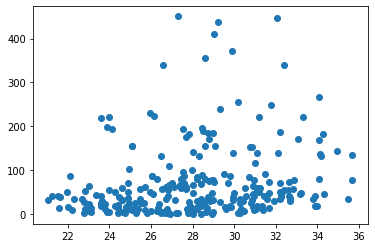

In [1417]:
plt.scatter(test['t_max'], test['pd_in'])

## Take out 공휴일

In [1418]:
holiday = ['2016-01-01', '2016-02-07','2016-02-08',
           '2016-02-09','2016-02-10', '2016-03-01',
          '2016-04-13', '2016-05-01', '2016-05-05',
          '2016-05-14', '2016-06-06', '2016-08-15',
          '2016-09-14', '2016-09-15', '2016-09-16',
          '2016-10-03', '2016-10-09', '2016-12-25']

In [1419]:
gk['holiday'] = gk['date'].isin(holiday)

In [1420]:
gk['isHW'] = (gk['t_max'] > 33).astype(int)

In [1421]:
for lag in range(1,8):
    gk[f'lag{lag}_isHW'] = (gk[f'lag{lag}_t_max'] > 33).astype(int)

## 1일도 뺌

In [1422]:

gk['HW_diff']  = np.where(gk['t_max'] <= 33, 0, gk['t_max'] - 33)

In [1423]:
for lag in range(1,8):
    gk[f'lag{lag}_HW_diff']  = np.where(gk[f'lag{lag}_t_max'] <= 33, 0, gk[f'lag{lag}_t_max'] - 33)

In [1424]:
gk['is_first'] = (gk['day'] == 1).astype(int)

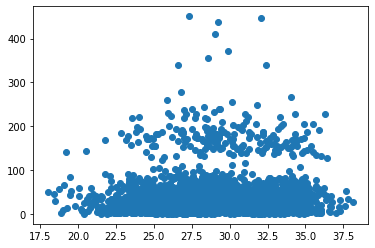

In [1425]:
plt.scatter(gk['t_max'], gk['pd_in'])

In [1426]:
gk['is_weekend'] = gk['weekdayname'].isin(['Saturday','Sunday'])

# Environmental Variable

In [1427]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
hu 
"""

In [1428]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1429]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1430]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1929
Model Family:                 Poisson   Df Model:                           19
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9514.7
Date:                Sat, 30 Nov 2019   Deviance:                       9179.1
Time:                        19:07:18   Pearson chi2:                 8.79e+03
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3027      0

# Lag 0

In [1431]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
hu +
HW_diff
"""

In [1432]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1433]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1434]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1928
Model Family:                 Poisson   Df Model:                           20
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9510.0
Date:                Sat, 30 Nov 2019   Deviance:                       9169.7
Time:                        19:07:25   Pearson chi2:                 8.78e+03
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.3171      0

# Lag 4

In [1435]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
lag4_isHW
"""

In [1436]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1437]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

In [1438]:
print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                 1949
Model:                            GLM   Df Residuals:                     1929
Model Family:                 Poisson   Df Model:                           19
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -9525.0
Date:                Sat, 30 Nov 2019   Deviance:                       9199.8
Time:                        19:07:40   Pearson chi2:                 8.82e+03
No. Iterations:                     6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.1367      0

# Lag 6


In [1439]:
expr = """pd_in ~ 
holiday +
is_weekend +
place +
is_first + 
lag6_isHW
"""

In [1440]:
y, X = dmatrices(expr, gk, return_type='dataframe')

In [1441]:
poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

## 질환있는 사람

In [1476]:
seoul = gk[gk['place']=='BS']

In [1477]:
Counter(seoul['isHW'])

Counter({0: 114, 1: 8})

In [1479]:
expr = """pd_in ~ 
holiday +
is_weekend +
is_first + 
hu +
isHW
"""

y, X = dmatrices(expr, seoul, return_type='dataframe')

poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()

print(poisson_training_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  pd_in   No. Observations:                  122
Model:                            GLM   Df Residuals:                      116
Model Family:                 Poisson   Df Model:                            5
Link Function:                    log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -555.71
Date:                Sat, 30 Nov 2019   Deviance:                       475.66
Time:                        19:10:25   Pearson chi2:                     441.
No. Iterations:                     7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.0442      0

### 

In [936]:
gk.to_csv('../data/processed.csv')

In [939]:
test = pd.read_csv("../data/2016_1.csv", encoding='EUC-KR')

In [940]:
test

,지역,측정소코드,측정소명,측정일시,SO2,CO,O3,NO2,PM10,PM25,주소
0,강원 강릉시,632132,옥천동,2016010101,0.004,0.6,0.023,0.015,47.0,38.0,강원 강릉시 옥천동
1,강원 강릉시,632132,옥천동,2016010102,0.004,0.6,0.024,0.015,51.0,43.0,강원 강릉시 옥천동
2,강원 강릉시,632132,옥천동,2016010103,0.004,0.6,0.024,0.014,52.0,44.0,강원 강릉시 옥천동
3,강원 강릉시,632132,옥천동,2016010104,0.003,0.6,0.024,0.013,45.0,38.0,강원 강릉시 옥천동
4,강원 강릉시,632132,옥천동,2016010105,0.004,0.6,0.025,0.013,43.0,37.0,강원 강릉시 옥천동
...,...,...,...,...,...,...,...,...,...,...,...
698875,충북 충주시,633123,칠금동,2016033120,0.004,1.0,0.009,0.086,91.0,25.0,충북 충주시 칠금동
698876,충북 충주시,633123,칠금동,2016033121,0.004,0.8,0.009,0.068,123.0,35.0,충북 충주시 칠금동
698877,충북 충주시,633123,칠금동,2016033122,0.004,0.8,0.009,0.062,133.0,46.0,충북 충주시 칠금동
698878,충북 충주시,633123,칠금동,2016033123,0.004,0.8,0.008,0.057,137.0,52.0,충북 충주시 칠금동


In [1138]:
list(Counter(gk['place']).keys())

['BS',
 'CB',
 'CN',
 'DG',
 'DJ',
 'GB',
 'GG',
 'GJ',
 'GN',
 'GW',
 'IC',
 'JB',
 'JJ',
 'JN',
 'SU',
 'US']

## By city

In [1270]:
variables = [
    'isHW'
]
for i in range(1,8):
    variables.append(f'lag{i}_isHW')
variables.append('HW_diff')
for i in range(1,8):
    variables.append(f'lag{i}_HW_diff')

In [1271]:
def equat(x):
    return (x-1)/x

In [1273]:
import math
import xlsxwriter
writer = pd.ExcelWriter('../data/june_glm.xlsx', engine='xlsxwriter')
for city in list(Counter(gk['place']).keys()):
    info_dict = {}
    for variable in variables:
        expr = f"""pd_in ~ 
        holiday +
        is_weekend +
        is_first + 
        hu +
        {variable}
        """
        gk_city = gk[gk['place'] == city]
        y, X = dmatrices(expr, gk_city, return_type='dataframe')
        poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()
        temp = {}
        temp['coefficient'] = poisson_training_results.params[variable]
        temp['pvalue'] = poisson_training_results.pvalues[variable]
        conf_interval = poisson_training_results.conf_int().iloc[5]
        low_conf, high_conf = conf_interval[0], conf_interval[1]
        temp['lowerCI'] = low_conf
        temp['higherCI'] = high_conf
        temp['RR'] = math.exp(temp['coefficient'])
        temp['lowerRRCI'] = math.exp(temp['lowerCI'])
        temp['higherRRCI'] = math.exp(temp['higherCI'])
        temp['AR'] = equat(temp['RR'])
        temp['lowerARCI'] = equat(temp['lowerRRCI'])
        temp['higherARCI'] = equat(temp['higherRRCI'])
        temp['isSignificant'] = poisson_training_results.pvalues[variable] < 0.05
        info_dict[variable] = temp
    s = pd.DataFrame(info_dict)
#     s.to_csv(f'../data/statistics/{city}.csv')
    s.to_excel(writer, sheet_name=f'{city}')
writer.save()

In [1274]:
info_dict = {}
for variable in variables:
    expr = f"""pd_in ~ 
    holiday +
    is_weekend +
    is_first + 
    hu +
    place +
    {variable}
    """
    gk_city = gk
    y, X = dmatrices(expr, gk_city, return_type='dataframe')
    poisson_training_results = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    temp = {}
    temp['coefficient'] = poisson_training_results.params[variable]
    temp['pvalue'] = poisson_training_results.pvalues[variable]
    conf_interval = poisson_training_results.conf_int().iloc[-1]
    low_conf, high_conf = conf_interval[0], conf_interval[1]
    temp['lowerCI'] = low_conf
    temp['higherCI'] = high_conf
    temp['RR'] = math.exp(temp['coefficient'])
    temp['lowerRRCI'] = math.exp(temp['lowerCI'])
    temp['higherRRCI'] = math.exp(temp['higherCI'])
    temp['AR'] = equat(temp['RR'])
    temp['lowerARCI'] = equat(temp['lowerRRCI'])
    temp['higherARCI'] = equat(temp['higherRRCI'])
    temp['isSignificant'] = poisson_training_results.pvalues[variable] < 0.05
    info_dict[variable] = temp
s = pd.DataFrame(info_dict)
s.to_csv(f'../data/statistics/june_all.csv')

In [1276]:
list(Counter(gk['place']).keys())

['BS',
 'CB',
 'CN',
 'DG',
 'DJ',
 'GB',
 'GG',
 'GJ',
 'GN',
 'GW',
 'IC',
 'JB',
 'JJ',
 'JN',
 'SU',
 'US']

In [1277]:
interested_places = ['SU', 'BS', 'DG', 'GJ', 'DJ', 'IC', 'US']

In [1289]:
gk.columns

Index(['kma_jid', 't_max', 'hu', 'lag1_t_max', 'lag1_hu', 'lag2_t_max',
       'lag2_hu', 'lag3_t_max', 'lag3_hu', 'lag4_t_max', 'lag4_hu',
       'lag5_t_max', 'lag5_hu', 'lag6_t_max', 'lag6_hu', 'lag7_t_max',
       'lag7_hu', 'pd_in', 'date', 'place', 'month', 'day_of_week', 'day',
       'weekdayname', 'holiday', 'isHW', 'lag1_isHW', 'lag2_isHW', 'lag3_isHW',
       'lag4_isHW', 'lag5_isHW', 'lag6_isHW', 'lag7_isHW', 'HW_diff',
       'lag1_HW_diff', 'lag2_HW_diff', 'lag3_HW_diff', 'lag4_HW_diff',
       'lag5_HW_diff', 'lag6_HW_diff', 'lag7_HW_diff', 'is_first',
       'is_weekend'],
      dtype='object')

In [1343]:
finished_city = []

In [1357]:
city = 'US'
temp = gk[gk['place'] == city]

finished_city.append(city)
temp.describe()['t_max']

count    122.000000
mean      27.886066
std        3.749718
min       18.900000
25%       25.025000
50%       27.550000
75%       30.750000
max       35.700000
Name: t_max, dtype: float64

Text(0.5, 1.0, 'Density Plot and Histogram of T_max in US')

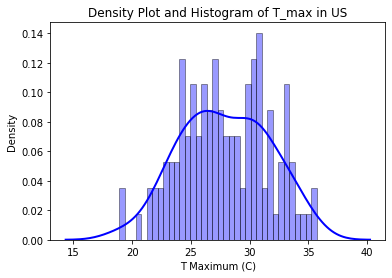

In [1358]:
import seaborn as sns
# seaborn histogram
sns.distplot(temp['t_max'], hist=True, kde=True, 
             bins=int(180/5), color = 'blue',
             hist_kws={'edgecolor':'black'}, kde_kws={'linewidth': 2})
plt.xlabel("T Maximum (C)")
plt.ylabel("Density")
plt.title(f"Density Plot and Histogram of T_max in {city}")

Text(0.5, 1.0, 'Change in temperature in US')

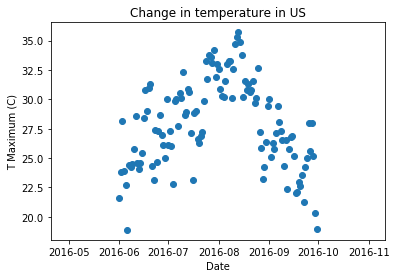

In [1359]:
plt.scatter(temp['date'], temp['t_max'])
plt.xlabel("Date")
plt.ylabel("T Maximum (C)")
plt.title(f"Change in temperature in {city}")

Text(0.5, 1.0, 'T_max vs Pd_in in US')

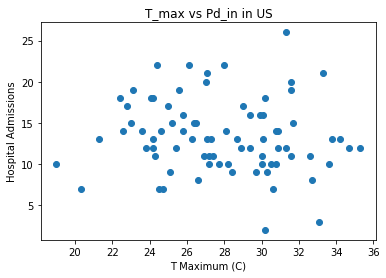

In [1360]:
temp1 = temp[~temp['is_weekend'] & ~temp['is_first'] & ~temp['holiday']]
plt.scatter(temp1['t_max'], temp1['pd_in'])
plt.xlabel("T Maximum (C)")
plt.ylabel("Hospital Admissions")
plt.title(f"T_max vs Pd_in in {city}")

In [1361]:
finished_city

['GJ', 'GJ', 'IC', 'SU', 'US']

In [1366]:
parkinson_code = ['G20','G21','G22']
gastro_code = ['K50', 'K52', 'K58', 'K59', 'A08', 'A09', 'A05', 'R13', 'R12', 'R11', 'R10']

In [1364]:
gastro_df = patients_df[patients_df['sick_cha3'].isin(gastro_code)]

In [1369]:
gastro_df.shape

(279834, 139)

In [1392]:
parkinson_df = patients_df[patients_df['sick_cha3'].isin(parkinson_code)]

In [1402]:
parkinson_df['no'].unique().shape

(36595,)

In [1403]:
patients_df['no'].unique().shape

(36595,)

In [1394]:
total_patients = patients_df['no'].unique()

In [1395]:
len(total_patients)

36595

In [1396]:
parkinson_patients = parkinson_df['no'].unique()

In [1397]:
len(parkinson_patients)

36595

In [1390]:
gastro_parkinson_patients = gastro_df[gastro_df['no'].isin(parkinson_patients)]['no'].unique()
gastro_patients = gastro_df['no'].unique()

In [1391]:
print(f'number of total patients: {len(total_patients)}')
print(f'number of parkinson patients: {len(parkinson_patients)}')
print(f'proportion of parkinson patients of all: {len(parkinson_patients)/len(total_patients)}')
print(f'number of gastro patients: {len(gastro_patients)}')
print(f'number of parkinson + gastro patients: {len(gastro_parkinson_patients)}')
print(f'proportion of parkinson out of all gastro: {len(gastro_parkinson_patients)/len(gastro_patients)}')

number of total patients: 36595
number of parkinson patients: 36595
proportion of parkinson patients of all: 1.0
number of gastro patients: 26106
number of parkinson + gastro patients: 26106
proportion of parkinson out of all gastro: 1.0
